# Day 08. Exercise 04
# Regression

## 0. Imports

In [466]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [ ]:
df=pd.read_csv("../data/checker_regression.csv")
df.isna().sum()

uid             0
num_commits     0
pageviews      18
AVG(diff)      59
dtype: int64

In [468]:
df=df.fillna(0)
df=df.drop_duplicates()
df=df.drop(['uid'], axis=1)

In [469]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 0 to 76
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   num_commits  29 non-null     int64  
 1   pageviews    29 non-null     float64
 2   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 928.0 bytes


In [470]:
'''
category = ['uid']
number = ['num_commits', 'pageviews']

ohe = OneHotEncoder(sparse_output=False)
encoded_category = ohe.fit_transform(df[category])
encoded_df = pd.DataFrame(encoded_category, columns=ohe.get_feature_names_out(category))

scaler = StandardScaler()
scaled_number = scaler.fit_transform(df[number])
scaled_df = pd.DataFrame(scaled_number, columns=number)

df_final = pd.concat([encoded_df, scaled_df, df['AVG(diff)'].reset_index(drop=True)], axis=1)
df_final
'''

"\ncategory = ['uid']\nnumber = ['num_commits', 'pageviews']\n\nohe = OneHotEncoder(sparse_output=False)\nencoded_category = ohe.fit_transform(df[category])\nencoded_df = pd.DataFrame(encoded_category, columns=ohe.get_feature_names_out(category))\n\nscaler = StandardScaler()\nscaled_number = scaler.fit_transform(df[number])\nscaled_df = pd.DataFrame(scaled_number, columns=number)\n\ndf_final = pd.concat([encoded_df, scaled_df, df['AVG(diff)'].reset_index(drop=True)], axis=1)\ndf_final\n"

In [471]:
X=df.drop('AVG(diff)', axis=1)
y=df['AVG(diff)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [472]:
def crossval(n_splits, X, y, model):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)
    
    test_scores = []
    
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        iter=clone(model)
        iter.fit(X_train, y_train)
        y_train_pred = iter.predict(X_train)
        y_test_pred = iter.predict(X_test)
        
        rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
        rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
        print(f"train -  {rmse_train}   |   test -  {rmse_test}")
        
        test_scores.append(rmse_test)
    
    print(f"Average RMSE on crossval is {np.mean(test_scores)}")
    model.fit(X, y)
    return model

In [473]:
model_lr=crossval(10, X_train, y_train, LinearRegression())

train -  53.33351096491692   |   test -  115.2394318363867
train -  62.409919772255556   |   test -  69.35808794733022
train -  64.75146423244131   |   test -  52.395419621714424
train -  64.04094981627755   |   test -  78.18810821407222
train -  63.574089717062186   |   test -  58.669554693832154
train -  65.40154560181439   |   test -  32.10068854674121
train -  64.40600245557161   |   test -  48.59322878192214
train -  61.215472663804725   |   test -  82.41734194163652
train -  64.69372263304507   |   test -  43.81163345544473
train -  62.80195740062014   |   test -  70.47228900535454
Average RMSE on crossval is 65.1245784044435


In [474]:
model_dt=crossval(10, X_train, y_train, DecisionTreeRegressor(random_state=21, max_depth=5, min_samples_leaf=10))

train -  56.275401486795275   |   test -  118.81458886370753
train -  62.673287870511466   |   test -  87.52559867346322
train -  67.61337478635421   |   test -  62.00078440364014
train -  65.63955269001211   |   test -  72.78122476145738
train -  66.31879061364123   |   test -  59.296329378619866
train -  67.4910196046313   |   test -  60.9103441187222
train -  66.92605612506976   |   test -  53.01639536763865
train -  64.30207696374863   |   test -  82.58720442491212
train -  68.0172856499445   |   test -  49.982259042666975
train -  66.46302904832866   |   test -  59.92525495840347
Average RMSE on crossval is 70.68399839932316


In [475]:
model_rf=crossval(10, X_train, y_train, RandomForestRegressor(random_state=21, n_estimators=100, max_depth=25))

train -  19.85306588532919   |   test -  76.53685427174808
train -  22.671373358544045   |   test -  81.61793883314117
train -  21.694829255044976   |   test -  5.71235319286195
train -  22.7272784086383   |   test -  9.177142450433891
train -  24.38477655695876   |   test -  70.14702143355767
train -  19.90791216218836   |   test -  40.07320878716852
train -  20.52570355431141   |   test -  55.68347292110613
train -  22.325869971584417   |   test -  22.92156316416678
train -  18.972031532693418   |   test -  26.447489505149523
train -  16.687043596636038   |   test -  69.28195592288081
Average RMSE on crossval is 45.759900048221446


## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

In [476]:
y_pred=model_lr.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(52.69818584468258)

In [477]:
y_pred=model_dt.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(71.9626574919857)

In [478]:
y_pred=model_rf.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(84.31184698432014)

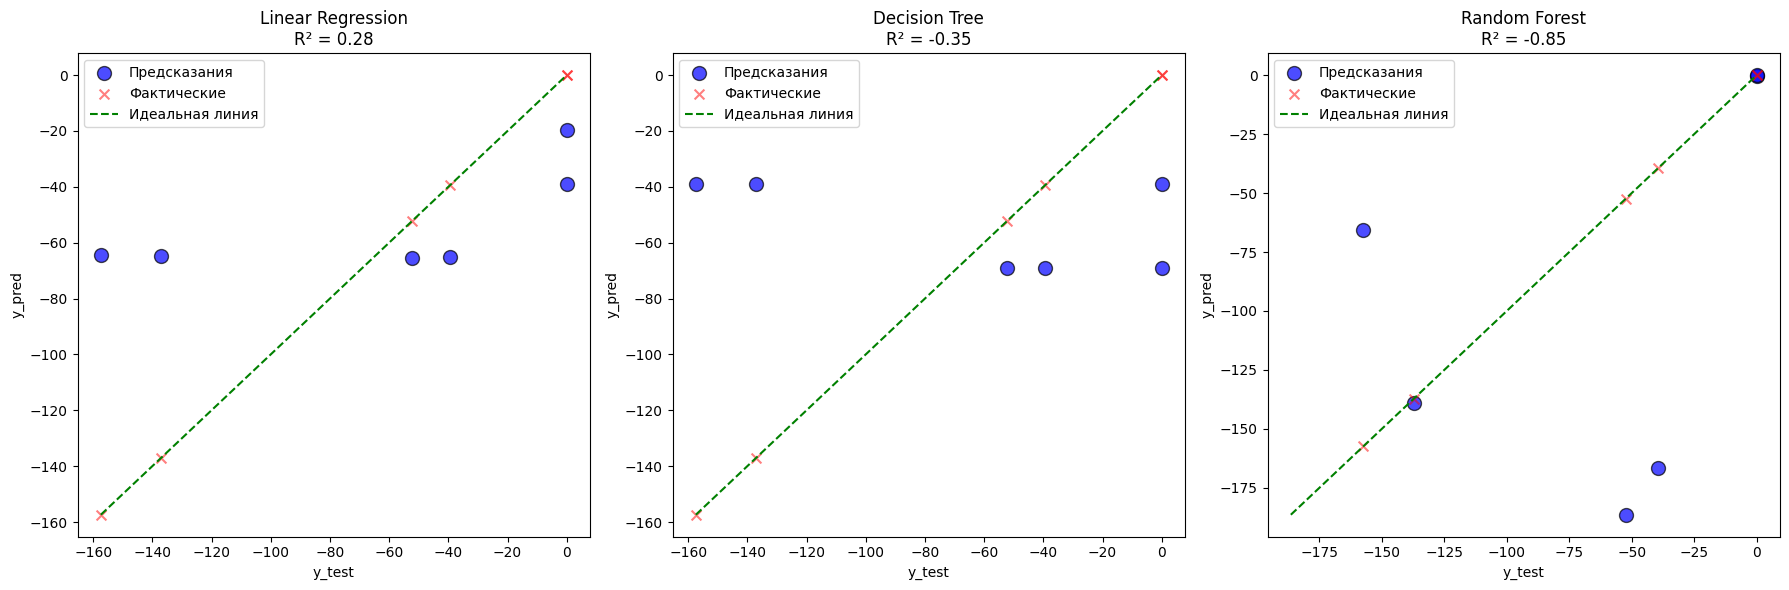

In [479]:
models = {
    "Linear Regression": model_lr,
    "Decision Tree": model_dt,
    "Random Forest": model_rf
}

plt.figure(figsize=(18, 6))

for idx, (name, model) in enumerate(models.items(), 1):
    
    y_pred = model.predict(X_test)
    
    
    plt.subplot(1, 3, idx)
    plt.scatter(y_test, y_pred, alpha=0.7, s=100, color='blue', edgecolor='k', label='Предсказания')
    plt.scatter(y_test, y_test, alpha=0.5, s=50, color='red', marker='x', label='Фактические')
    
    
    ideal_line = np.linspace(min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max()), 100)
    plt.plot(ideal_line, ideal_line, 'g--', label='Идеальная линия')
    
    
    plt.xlabel('y_test')
    plt.ylabel('y_pred')
    plt.title(f'{name}\nR² = {model.score(X_test, y_test):.2f}')
    plt.legend()

plt.tight_layout()
plt.show()

"How would plot look like in the ideal case?" **Диагональ**